In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from torch.optim import AdamW
from tqdm.auto import tqdm

num_epochs = 1
learning_rate = 5e-5

optimizer = AdamW(model.parameters(), lr=learning_rate)

model.train()

max_steps = 80  # ندرّب على 80 خطوة بس للتجربة

for epoch in range(num_epochs):
    total_loss = 0.0

    for step, batch in enumerate(tqdm(train_dataloader)):  # استخدمنا train_dataloader
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        if (step + 1) % 20 == 0:
            print(f"Epoch {epoch+1} | Step {step+1} | Loss: {loss.item():.4f}")

        # نوقف بعد عدد معيّن من الخطوات عشان ما يطوّل
        if (step + 1) >= max_steps:
            break

    avg_loss = total_loss / (step + 1)
    print(f"\nEpoch {epoch+1} finished. Avg loss = {avg_loss:.4f}\n")


  0%|          | 0/125 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1 | Step 20 | Loss: 4.8315
Epoch 1 | Step 40 | Loss: 5.0201
Epoch 1 | Step 60 | Loss: 4.1382


In [30]:
!pip install gtts


In [31]:
import gradio as gr
from PIL import Image
import torch
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from gtts import gTTS

# تحميل المودل
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
processor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def generate_caption(image):
    image = Image.fromarray(image).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    output_ids = model.generate(pixel_values, max_length=16, num_beams=4)
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    # تحويل لصوت
    tts = gTTS(caption, lang="en")
    audio_path = "audio.mp3"
    tts.save(audio_path)

    return caption, audio_path

interface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="numpy"),
    outputs=[gr.Text(), gr.Audio()],
    title="Smart Glasses Captioning API"
)

interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a8614fe64bd698c0f1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
!pip install gtts gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1


In [3]:
import os, glob, re, random
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from gtts import gTTS
import gradio as gr


In [4]:
dataset_root  = "/content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k"
images_dir    = dataset_root + "/Images"
captions_path = dataset_root + "/captions.txt"
save_dir      = dataset_root + "/my_finetuned_caption_model"


In [5]:
dataset_root = "/content/drive/MyDrive/effat/Full2025/NLP/project/datasets/Flickr8k"

images_dir = dataset_root + "/Images"
captions_path = dataset_root + "/captions.txt"

print("Images dir:", images_dir)
print("Captions file:", captions_path)


Images dir: /content/drive/MyDrive/effat/Full2025/NLP/project/datasets/Flickr8k/Images
Captions file: /content/drive/MyDrive/effat/Full2025/NLP/project/datasets/Flickr8k/captions.txt


In [6]:
dataset_root = "/content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k"
save_dir = dataset_root + "/my_finetuned_caption_model"
print("Model folder:", save_dir)


Model folder: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/my_finetuned_caption_model


In [7]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
import torch
from IPython.display import display

model = VisionEncoderDecoderModel.from_pretrained(save_dir)
processor = ViTImageProcessor.from_pretrained(save_dir)
tokenizer = AutoTokenizer.from_pretrained(save_dir)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

device


'cpu'

In [8]:
def caption_image(image_path):
    image = Image.open(image_path).convert("RGB")
    display(image)

    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    output_ids = model.generate(pixel_values, max_length=16, num_beams=4)
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print("Image path:", image_path)
    print("Generated caption:", caption)


Number of images: 987


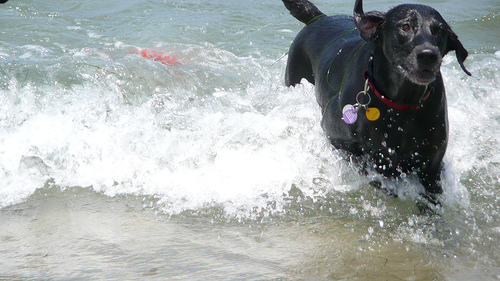

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Image path: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/Images/1022975728_75515238d8.jpg
Generated caption:  brown is in water a in the . . . . . . . .


In [9]:
#يجرّب الموديل على صور من نفس الداتا اللي تدرب عليها (Flickr8k)
import glob, os

images_dir = dataset_root + "/Images"
image_paths = glob.glob(os.path.join(images_dir, "*.jpg"))
print("Number of images:", len(image_paths))

test_image_path = image_paths[2]   # أو غيّري الرقم
caption_image(test_image_path)


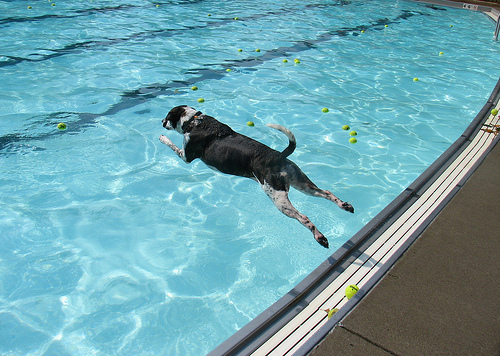

Image path: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/Images/1348113612_5bfc5f429e.jpg
Generated caption:  dog jumping a into pool a diving into pool a . . . . .


In [10]:
import random

test_image_path = random.choice(image_paths)
caption_image(test_image_path)


In [11]:
#لتثبيت المكتبات
!pip install -q transformers datasets accelerate sentencepiece

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os, zipfile, glob, re

from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

# -----  vit-gpt2-image-captioning تحميل المودل الجاهز -----
model_name = "nlpconnect/vit-gpt2-image-captioning"

model = VisionEncoderDecoderModel.from_pretrained(model_name)
processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# إعدادات مهمة للـ padding
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id
model.config.decoder_start_token_id = getattr(tokenizer, "bos_token_id", tokenizer.eos_token_id)
model.config.vocab_size = model.config.decoder.vocab_size

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

device


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

'cpu'

In [15]:
# نحدّد الجذر الجديد للداتا
dataset_root  = "/content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k"

images_dir    = dataset_root + "/Images"
captions_path = dataset_root + "/captions.txt"

print("Images dir:", images_dir)
print("Captions path:", captions_path)


Images dir: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/Images
Captions path: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/captions.txt


In [16]:
#يربط الصور مع الجمل
import glob, os, re, pandas as pd

print("Images dir:", images_dir)
print("Captions path:", captions_path)

# 1) نجيب كل الصور .jpg (حتى لو في سبت فولدرز)
image_paths = glob.glob(os.path.join(images_dir, "**", "*.jpg"), recursive=True)
print("Number of jpg images found:", len(image_paths))

# خريطة: اسم الصورة -> المسار الكامل
name_to_path = {os.path.basename(p): p for p in image_paths}

# 2) نقرأ captions.txt ونستخرج (image_file, caption) باستخدام regex مرن
pattern = re.compile(r'^(\S+?\.jpg)(?:#\d+)?[ \t,]+(.*)$')

image_list = []
caption_list = []

with open(captions_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        m = pattern.match(line)
        if not m:
            # سطر مو منسّق زي باقي السطور، نطنّشه
            continue

        img_file = m.group(1)          # اسم الصورة xxx.jpg
        cap = m.group(2).strip()       # النص

        full_path = name_to_path.get(img_file)
        if not full_path:
            # ما لقينا الصورة (مثلاً مو موجودة في Images)
            continue

        image_list.append(full_path)
        caption_list.append(cap)

df = pd.DataFrame({"image_path": image_list, "caption": caption_list})

print("Rows in df:", len(df))
df.head()


Images dir: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/Images
Captions path: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/captions.txt
Number of jpg images found: 987
Rows in df: 4930


,image_path,caption
0,/content/drive/MyDrive/NLP/smart_glasses_datas...,A child in a pink dress is climbing up a set o...
1,/content/drive/MyDrive/NLP/smart_glasses_datas...,A girl going into a wooden building .
2,/content/drive/MyDrive/NLP/smart_glasses_datas...,A little girl climbing into a wooden playhouse .
3,/content/drive/MyDrive/NLP/smart_glasses_datas...,A little girl climbing the stairs to her playh...
4,/content/drive/MyDrive/NLP/smart_glasses_datas...,A little girl in a pink dress going into a woo...


In [17]:
# نختار subset
# التدريب
max_samples = min(1000, len(df))
df_train = df.iloc[:max_samples].reset_index(drop=True)
print("Using samples:", len(df_train))

class ImageCaptionDataset(Dataset):
    def __init__(self, df, processor, tokenizer, max_length=32):
        self.df = df
        self.processor = processor
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        pixel_values = processor(images=image, return_tensors="pt").pixel_values[0]

        caption = str(row["caption"])
        tok = tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        labels = tok.input_ids[0]
        labels[labels == tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels,
        }

train_dataset = ImageCaptionDataset(df_train, processor, tokenizer)
print("Dataset size:", len(train_dataset))

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)


Using samples: 1000
Dataset size: 1000


In [19]:
save_dir = dataset_root + "/my_finetuned_caption_model"

model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("Saved model to:", save_dir)


Saved model to: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/my_finetuned_caption_model


Test image path: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/Images/1000268201_693b08cb0e.jpg


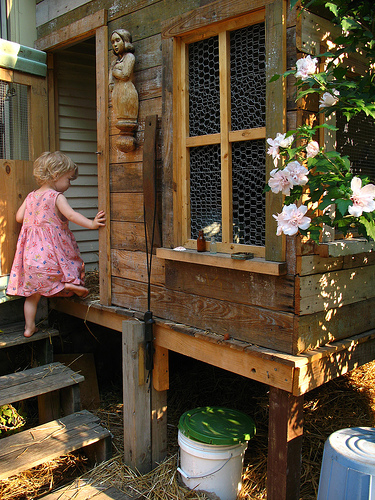

Generated caption: a little girl standing next to a wooden house 


In [20]:
from IPython.display import display

# نختار أول صورة من df_train (الـ subset اللي حددناه للتدريب)
test_image_path = df_train.iloc[0]["image_path"]
print("Test image path:", test_image_path)

image = Image.open(test_image_path).convert("RGB")
display(image)

# نولّد كابشن من الموديل الحالي (الجاهز أو الـ fine-tuned حسب اللي محملته)
pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
output_ids = model.generate(pixel_values, max_length=16, num_beams=4)
caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("Generated caption:", caption)


In [21]:
#مهمّة عشان تحميل الموديل
model = VisionEncoderDecoderModel.from_pretrained(save_dir)
processor = ViTImageProcessor.from_pretrained(save_dir)
tokenizer = AutoTokenizer.from_pretrained(save_dir)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [22]:
#واجهة Gradio والصوت
def generate_caption(image):
    # image جايه من Gradio كـ numpy array
    image = Image.fromarray(image).convert("RGB")

    # تحويل للصورة لمدخلات المودل
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    # توليد كابشن
    output_ids = model.generate(pixel_values, max_length=16, num_beams=4)
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    # تحويل الكابشن لصوت
    tts = gTTS(caption, lang="en")
    audio_path = "audio.mp3"
    tts.save(audio_path)

    return caption, audio_path


In [23]:
interface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="numpy", label="Upload image"),
    outputs=[
        gr.Textbox(label="Caption"),
        gr.Audio(label="Speech", type="filepath")
    ],
    title="Smart Glasses Captioning (Fine-tuned)"
)

interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0b24c3c6a6d3f10f7b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


test

In [24]:
# (تحميل الموديل من save_dir)
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
import torch
from IPython.display import display

# عدّلي المسار ع حسب اللي استخدمناه قبل
save_dir = "/content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/my_finetuned_caption_model"  # <-- اكتبي المسار الصح

model = VisionEncoderDecoderModel.from_pretrained(save_dir)
processor = ViTImageProcessor.from_pretrained(save_dir)
tokenizer = AutoTokenizer.from_pretrained(save_dir)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

device


'cpu'

In [25]:
# هذه دالة (function) نادّيها لما تبين الموديل يكتب كابشن لصورة معيّنة.
def caption_image(image_path):
    image = Image.open(image_path).convert("RGB")
    display(image)

    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    output_ids = model.generate(pixel_values, max_length=16, num_beams=4)
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print("Image path:", image_path)
    print("Generated caption:", caption)


In [26]:
# عدد الصفوف في الـ DF
len(df)


4930

Total rows: 4930


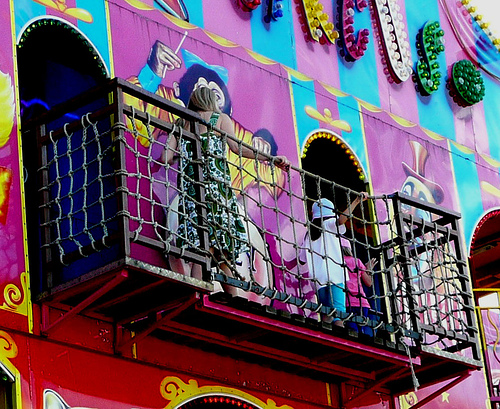

Image path: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/Images/1332492622_8c66992b62.jpg
Generated caption: a building with a mural painted on the side of it 


In [27]:

print("Total rows:", len(df))

test_idx = 1500    # رقم بين 1000 و len(df)-1
test_image_path = df.iloc[test_idx]["image_path"]

caption_image(test_image_path)


Chosen index: 1130


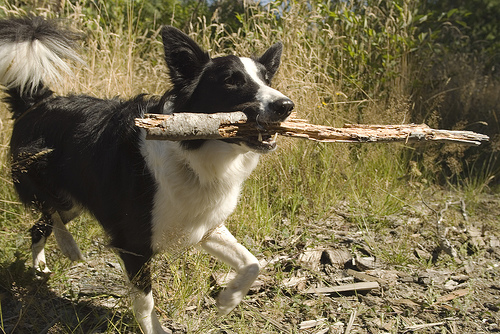

Image path: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/Images/1267711451_e2a754b4f8.jpg
Generated caption: a black and white dog with a stick in its mouth 


In [28]:
# قم عشوائي كل مرة من الصور اللي ما دخلت في التدريب
import random

n = len(df)
test_idx = random.randint(1000, n-1)
print("Chosen index:", test_idx)

test_image_path = df.iloc[test_idx]["image_path"]
caption_image(test_image_path)


Chosen index: 24


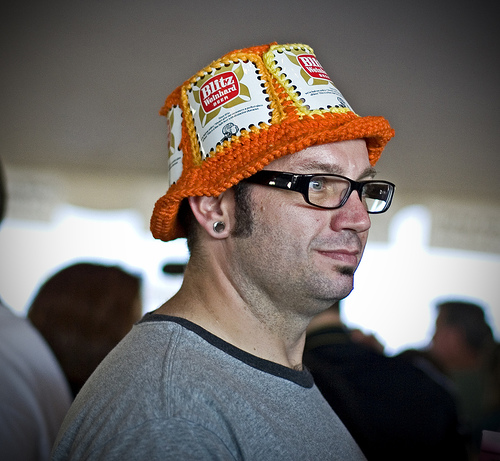

Image path: /content/drive/MyDrive/NLP/smart_glasses_dataset/Flickr8k/Images/1007129816_e794419615.jpg
Generated caption: a man wearing a hat and sunglasses 


In [29]:
def caption_image(image_path):
    image = Image.open(image_path).convert("RGB")
    display(image)

    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    output_ids = model.generate(pixel_values, max_length=16, num_beams=4)
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print("Image path:", image_path)
    print("Generated caption:", caption)

# اختبار على صورة من df خارج التدريب
import random

n = len(df)
test_idx = 24   # مثلاً

#test_idx = random.randint(1000, n-1)  # خارج أول 1000
print("Chosen index:", test_idx)

test_image_path = df.iloc[test_idx]["image_path"]
caption_image(test_image_path)


In [31]:
from google.colab import files

uploaded = files.upload()  # اختاري أي صورة من لابتوبك

for fname in uploaded.keys():
    caption_image(fname)


accuracy

In [43]:
from PIL import Image
from tqdm.auto import tqdm
import torch

def compute_caption_accuracy(model, df_eval, num_samples=200):
    """
    تحسب نسبة الكابشنات اللي طلعها الموديل
    مطابقة تماماً للكابشن الصحيح في df_eval.
    """
    model.eval()
    correct = 0
    total = 0

    # نختار عينة للتقييم (200 صف افتراضياً)
    subset = df_eval.sample(
        n=min(num_samples, len(df_eval)),
        random_state=42
    ).reset_index(drop=True)

    with torch.no_grad():
        for _, row in tqdm(subset.iterrows(), total=len(subset)):
            # 1) نقرأ الصورة
            image = Image.open(row["image_path"]).convert("RGB")
            pixel_values = processor(
                images=image,
                return_tensors="pt"
            ).pixel_values.to(device)

            # 2) نولّد الكابشن
            output_ids = model.generate(
                pixel_values,
                max_length=16,
                num_beams=4
            )
            pred_caption = tokenizer.decode(
                output_ids[0],
                skip_special_tokens=True
            ).strip().lower()

            # 3) الكابشن الصحيح من الداتا
            ref_caption = str(row["caption"]).strip().lower()

            # 4) نحسب إذا متطابقين تماماً
            if pred_caption == ref_caption:
                correct += 1

            total += 1

    accuracy = correct / total if total > 0 else 0.0
    return accuracy


In [45]:
# لو دربتي على أول 1000 صف، ممكن تقيمين على الباقي:
df_eval = df.iloc[1000:].reset_index(drop=True)

acc = compute_caption_accuracy(model, df_eval, num_samples=100)
print(f"Exact caption accuracy: {acc:.3f}")


  0%|          | 0/100 [00:00<?, ?it/s]

Exact caption accuracy: 0.000
